# Raport ewaluacji testu A/B:

Notatnik dokumentuje ewaluację testu A/B przeprowadzonego na mikroserwisie Nocarz, analiza opiera się na logach zawartych w pliku `logs_ab_test.jsonl`.

**Cele analizy:**
1. Weryfikacja poprawności rozkładu ruchu między wariantami.
2. Ocena wydajności systemu (zgodność z SLA).

In [6]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Loading microservice logs...")
log_data = []
with open('logs_ab_test.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        log_data.append(json.loads(line))

df_list = []
for entry in log_data:
    res = entry.get('prediction_result', {})
    row = {
        'client_ip': entry.get('client_ip'),
        'ab_variant': entry.get('ab_variant'),
        'segment_used': res.get('segment_used', 'unknown'),
        'prediction_time_ms': res.get('prediction_time_ms', 0),
    }
    df_list.append(row)

df = pd.DataFrame(df_list)
print(f"Loaded {len(df)} logged requests.")
display(df.head())

Loading microservice logs...
Loaded 5000 logged requests.


,client_ip,ab_variant,segment_used,prediction_time_ms
0,118.22.231.120,B_Target,target_large,80.74
1,118.22.231.120,B_Target,target_large,3.14
2,118.22.231.120,B_Target,target_large,3.37
3,118.22.231.120,B_Target,target_large,2.96
4,118.22.231.120,B_Target,target_small,22.53


## 1. Weryfikacja rozkładu ruchu
Sprawdzamy, czy mechanizm przydziału do wariantów oparty na haszu MD5 adresu IP poprawnie podzielił unikalnych użytkowników między grupę kontrolną (A_Baseline), a grupę testową (B_Target). Zgodnie z ustawieniami w `config.json` 70% użytkowników powinno trafić do wariantu B, a 30% do wariantu A

/tmp/ipykernel_5829/2994930378.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=user_percentages.index, y=user_percentages.values, palette="viridis")


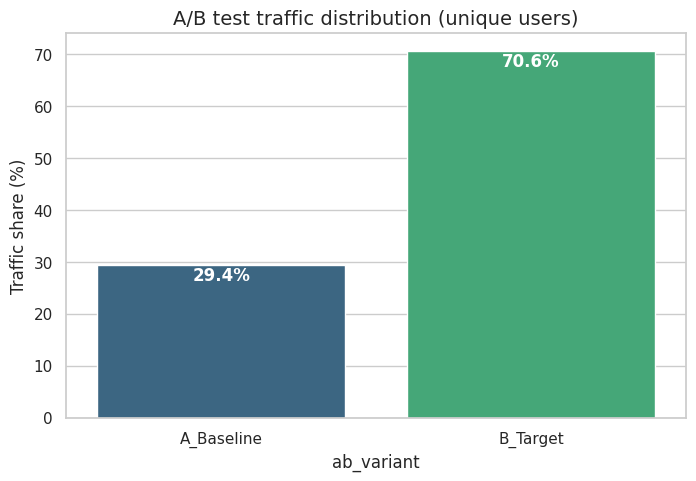

Number of unique IP addresses assigned to each variant:


,Unique users
ab_variant,
A_Baseline,294
B_Target,706


In [7]:
unique_users = df.groupby('ab_variant')['client_ip'].nunique()
user_percentages = (unique_users / unique_users.sum()) * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=user_percentages.index, y=user_percentages.values, palette="viridis")
plt.title("A/B test traffic distribution (unique users)", fontsize=14)
plt.ylabel("Traffic share (%)")

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height() - 2),
                ha='center', va='center', color='white', fontweight='bold')
plt.show()

print("Number of unique IP addresses assigned to each variant:")
display(unique_users.to_frame(name='Unique users'))

## 2. Wydajność systemu

Zgodnie z dokumentacją wstępną czas generowania predykcji powinien wynosić **maksymalnie 500 ms**. Poniższe wykresy i tabele przedstawiają:
- średni czas odpowiedzi w zależności od wybranego wariantu
- rozkład opóźnień w zależności od wybranego segmentu w wariancie B
- zestawienie średniego czasu odpowiedzi, wskaźników p95 i p99 oraz najdłuższego czasu odpowiedzi dla każdego zwariantów. 

/tmp/ipykernel_5829/1736242603.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=mean_latency.index, y=mean_latency.values, palette="rocket")


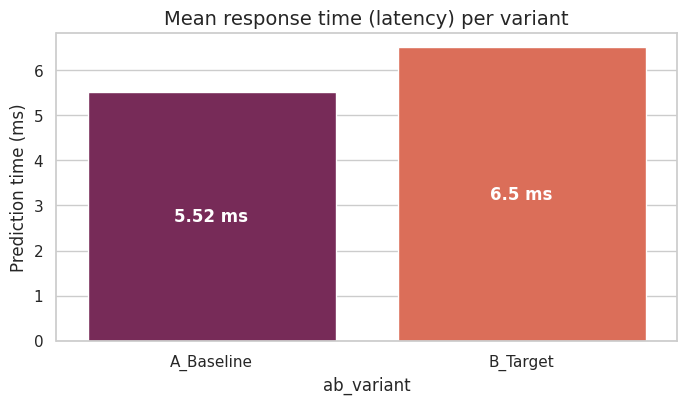

/tmp/ipykernel_5829/1736242603.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=b_data, x='segment_used', y='prediction_time_ms', palette="mako")


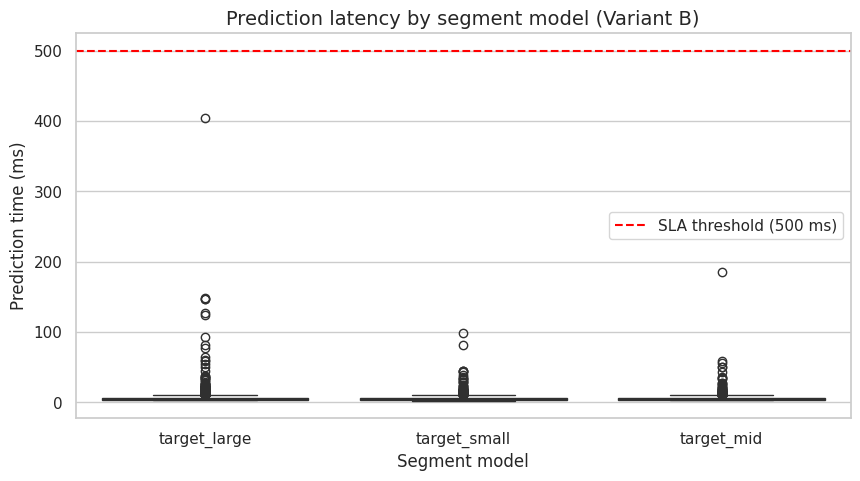


Latency by segment model in Variant B (Target):


,requests,mean,p95,p99,maximum
segment_used,,,,,
target_large,1774,6.77,13.95,34.93,404.52
target_mid,866,6.18,12.37,33.19,185.62
target_small,890,6.29,14.37,33.00,98.06



=== SLA compliance (500 ms) ===


,mean,p95,p99,maximum
ab_variant,,,,
A_Baseline,5.52,11.78,21.66,72.85
B_Target,6.50,13.62,34.33,404.52


B_Target: OK — no violations
A_Baseline: OK — no violations


In [8]:
SLA_THRESHOLD_MS = 500

mean_latency = df.groupby('ab_variant')['prediction_time_ms'].mean().round(2)

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=mean_latency.index, y=mean_latency.values, palette="rocket")
plt.title("Mean response time (latency) per variant", fontsize=14)
plt.ylabel("Prediction time (ms)")

for p in ax.patches:
    ax.annotate(f'{p.get_height()} ms',
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold')
plt.show()

if 'B_Target' in df['ab_variant'].values:
    b_data = df[df['ab_variant'] == 'B_Target']

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=b_data, x='segment_used', y='prediction_time_ms', palette="mako")
    plt.axhline(SLA_THRESHOLD_MS, color='red', linestyle='--', label=f'SLA threshold ({SLA_THRESHOLD_MS} ms)')
    plt.title("Prediction latency by segment model (Variant B)", fontsize=14)
    plt.ylabel("Prediction time (ms)")
    plt.xlabel("Segment model")
    plt.legend()
    plt.show()

    print("\nLatency by segment model in Variant B (Target):")
    b_segments = b_data.groupby('segment_used')['prediction_time_ms'].agg(
        requests='count',
        mean='mean',
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
        maximum='max'
    ).round(2)
    display(b_segments)

print(f"\n=== SLA compliance ({SLA_THRESHOLD_MS} ms) ===")
latency_stats = df.groupby('ab_variant')['prediction_time_ms'].agg(
    mean='mean',
    p95=lambda x: x.quantile(0.95),
    p99=lambda x: x.quantile(0.99),
    maximum='max'
).round(2)
display(latency_stats)

for variant in df['ab_variant'].unique():
    subset = df[df['ab_variant'] == variant]['prediction_time_ms']
    violations = (subset > SLA_THRESHOLD_MS).sum()
    pct = violations / len(subset) * 100
    status = "OK — no violations" if violations == 0 else f"VIOLATION: {violations} requests ({pct:.1f}%) exceeded {SLA_THRESHOLD_MS} ms"
    print(f"{variant}: {status}")